# Assignment 2

## Part 1: Fish Market Regression

### Q1. Linear Regression (15 points)

#### Import Libraries and Load Dataset

In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
import statsmodels.api as sm

import matplotlib.pyplot as plt

df = pd.read_excel("Fish.xls")
print(df.head())

  Species  Weight  Length1  Length2  Length3   Height   Width
0   Bream   242.0     23.2     25.4     30.0  11.5200  4.0200
1   Bream   290.0     24.0     26.3     31.2  12.4800  4.3056
2   Bream   340.0     23.9     26.5     31.1  12.3778  4.6961
3   Bream   363.0     26.3     29.0     33.5  12.7300  4.4555
4   Bream   430.0     26.5     29.0     34.0  12.4440  5.1340


In [6]:
print(df.columns)

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')


#### Define Features and Target

In [8]:
X = df[['Length1', 'Length2', 'Length3', 'Height', 'Width']]
y = df['Weight']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (111, 5)  Test size: (48, 5)


### Fit Linear Regression (OLS)

In [24]:
X_train_sm = sm.add_constant(X_train)  # Add intercept
ols = sm.OLS(y_train, X_train_sm).fit()

print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     167.0
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           2.66e-48
Time:                        14:54:10   Log-Likelihood:                -689.14
No. Observations:                 111   AIC:                             1390.
Df Residuals:                     105   BIC:                             1407.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -530.2590     36.848    -14.391      0.0

#### Estimated coefficients, R-squared term, and the 95% confidence interval

In [25]:
print("Coefficients (Least Squares Estimates):")
print(ols.params)

Coefficients (Least Squares Estimates):
const     -530.258960
Length1     32.691486
Length2     25.009744
Length3    -29.791039
Height      23.878024
Width       15.974163
dtype: float64


In [103]:
print("\nStandard Errors:")
print(ols.bse)


Standard Errors:
const      36.847650
Length1    52.628116
Length2    52.607849
Length3    19.314951
Height     10.262141
Width      23.600338
dtype: float64


In [27]:
print("\nR-squared:", ols.rsquared)
print("Adjusted R-squared:", ols.rsquared_adj)


R-squared: 0.8882734450295612
Adjusted R-squared: 0.8829531328881117


In [28]:
print("\n95% Confidence Intervals:")
print(ols.conf_int(alpha=0.05))


95% Confidence Intervals:
                  0           1
const   -603.321043 -457.196877
Length1  -71.660346  137.043319
Length2  -79.301903  129.321391
Length3  -68.089019    8.506941
Height     3.530094   44.225954
Width    -30.820946   62.769273


#### Finding dependence between the length and weight

In [29]:
print("p-values:")
print(ols.pvalues)


p-values:
const      1.380947e-26
Length1    5.358280e-01
Length2    6.354898e-01
Length3    1.259892e-01
Height     2.189513e-02
Width      4.999822e-01
dtype: float64


In [20]:
corr = df[['Weight', 'Length1', 'Length2', 'Length3']].corr()
print(corr['Weight'])


Weight     1.000000
Length1    0.915712
Length2    0.918618
Length3    0.923044
Name: Weight, dtype: float64


#### Is there any dependence between the length and weight of the fish?
Yes, there is strong dependence between fish length and weight.

The correlation coefficients between Weight and the length variables (Length1 = 0.9157, Length2 = 0.9186, Length3 = 0.9230) are very high, indicating a strong positive linear relationship. This means that as fish length increases, fish weight also increases significantly.

Additionally, the regression model has a high R² value of 0.888, showing that about 88.8% of the variation in weight is explained by the size-related variables. Although the individual p-values for the length variables are not significant due to multicollinearity, the overall analysis clearly indicates a strong dependence between fish length and weight.

### Q2. Ridge and Lasso Regression

#### Fit Ridge and Lasso Model and Report Coefficients

In [22]:
from sklearn.linear_model import Ridge, Lasso

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_coef = pd.Series(ridge.coef_, index=X.columns)
print("Ridge Coefficients:")
print(ridge_coef)

# Lasso Regression
lasso = Lasso(alpha=1.0, max_iter=10000)
lasso.fit(X_train, y_train)

lasso_coef = pd.Series(lasso.coef_, index=X.columns)
print("\nLasso Coefficients:")
print(lasso_coef)


Ridge Coefficients:
Length1    30.970924
Length2    25.243218
Length3   -28.474155
Height     23.229551
Width      16.819504
dtype: float64

Lasso Coefficients:
Length1    36.742802
Length2    16.515789
Length3   -25.291690
Height     22.379919
Width      17.703329
dtype: float64


### Least Impactful Attribute Based on Ridge and Lasso Regression
Based on the Ridge and Lasso results, Width is the least impactful attribute in predicting fish weight. In the Ridge model, Width has the smallest absolute coefficient (16.82), and in the Lasso model it also has one of the smallest coefficients (17.70). Since smaller coefficient magnitudes indicate weaker influence on the target variable, Width contributes the least to predicting fish weight.

### Q3. Model Testing

In [31]:
from sklearn.metrics import mean_squared_error, r2_score

# OLS
X_test_sm = sm.add_constant(X_test)
y_pred_ols = ols.predict(X_test_sm)

mse_ols = mean_squared_error(y_test, y_pred_ols)
r2_ols  = r2_score(y_test, y_pred_ols)

# Ridge
y_pred_ridge = ridge.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge  = r2_score(y_test, y_pred_ridge)

# Lasso
y_pred_lasso = lasso.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso  = r2_score(y_test, y_pred_lasso)

# Summary
results = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso"],
    "MSE":   [mse_ols, mse_ridge, mse_lasso],
    "R2":    [r2_ols,  r2_ridge,  r2_lasso]
})
print(results.sort_values(by="MSE"))
print("\nBest by MSE:", results.loc[results["MSE"].idxmin(), "Model"])
print("Best by R2:", results.loc[results["R2"].idxmax(), "Model"])


   Model           MSE        R2
2  Lasso  16203.776733  0.867718
0    OLS  16217.627414  0.867605
1  Ridge  16239.351882  0.867427

Best by MSE: Lasso
Best by R2: Lasso


### Analysis
Based on the test dataset results, Lasso regression performs the best, achieving the lowest MSE (16203.78) and the highest R² (0.8677). Although the differences among the three models are small, Lasso slightly outperforms OLS and Ridge, likely due to its stronger regularization effect, which helps reduce variance and improve generalization. Overall, all three models demonstrate similar performance, indicating a strong linear relationship between fish dimensions and weight.

## Part 2: Social Network Logistic Regression

### (a) Age and Salary Model 

#### Load Dataset

In [59]:
df = pd.read_csv("Social_Network_ads.csv")

print(df.head())
print(df.info())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None


#### Select Features

In [63]:
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

#### Train-Test Split

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (280, 2)
X_test shape: (120, 2)
y_train shape: (280,)
y_test shape: (120,)


#### Feature Scaling

In [65]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [52]:
print(X_train[:5])

[[-0.72378527 -0.69308934 -0.75425342 -0.63284698 -0.58010567]
 [-0.83421159 -0.81507103 -0.91108538 -0.95932281 -1.04308495]
 [ 0.75191187  0.73315817  0.65723425  0.49477347  1.44315024]
 [ 0.2198578   0.21708177  0.41327342  1.36998948  0.19796686]
 [ 0.40055541  0.3859795   0.22158991  0.28138565  0.92913387]]


#### Train Logistic Regression Model

In [66]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### Make Predictions

In [69]:
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]


#### Performance Metrics

In [71]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, roc_auc_score
)


In [73]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.85
Precision: 0.9393939393939394
Recall: 0.6595744680851063
F1 Score: 0.775


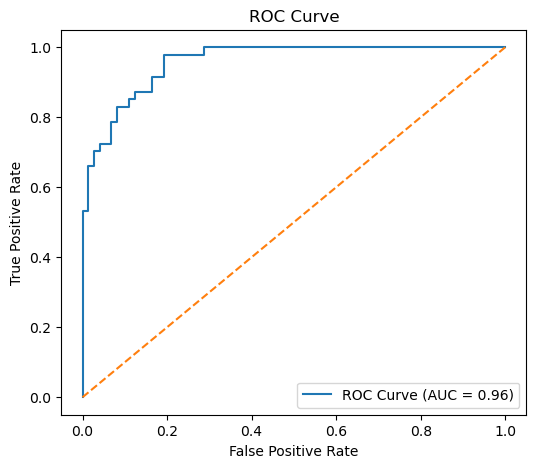

In [76]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(roc_auc))
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


 ### (b) Gender, Age, and Salary Model

#### Update the features

In [79]:
# Encode Gender: Female=0, Male=1
df["Gender_bin"] = df["Gender"].map({"Female": 0, "Male": 1})

X = df[["Gender_bin", "Age", "EstimatedSalary"]]
y = df["Purchased"]

#### Split the data (70/30) 

In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Keep gender labels for test rows so we can evaluate male/female separately
gender_test = df.loc[X_test.index, "Gender"]
print(gender_test)

300    Female
195      Male
215    Female
276      Male
395    Female
        ...  
342    Female
66       Male
109    Female
335    Female
224    Female
Name: Gender, Length: 120, dtype: object


#### Scale Age and Salary

In [82]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[["Age", "EstimatedSalary"]] = scaler.fit_transform(X_train[["Age", "EstimatedSalary"]])
X_test_scaled[["Age", "EstimatedSalary"]] = scaler.transform(X_test[["Age", "EstimatedSalary"]])


#### Train model

In [83]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### Make Predictions

In [93]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
# Put predictions into Series aligned with X_test index 
y_pred_s = pd.Series(y_pred, index=X_test.index)
y_prob_s = pd.Series(y_prob, index=X_test.index)

print(y_pred)
print(y_pred_s)

[1 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 1 0 0
 0 0 0 0 1 0 1 1 0 0 1 1 0 1 1 1 1 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1
 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0
 1 0 0 0 0 0 0 0 0]
300    1
195    0
215    1
276    0
395    0
      ..
342    0
66     0
109    0
335    0
224    0
Length: 120, dtype: int64


#### Function for Computing Metrics

In [94]:
def compute_group_metrics(group_name, mask):
    yt = y_test[mask]
    yp = y_pred_s[mask]
    ypr = y_prob_s[mask]

    metrics = {
        "Group": group_name,
        "n": int(mask.sum()),
        "Accuracy": accuracy_score(yt, yp),
        "Precision": precision_score(yt, yp, zero_division=0),
        "Recall": recall_score(yt, yp, zero_division=0),
        "F1": f1_score(yt, yp, zero_division=0),
        "AUC": roc_auc_score(yt, ypr) if len(np.unique(yt)) > 1 else np.nan
    }
    return metrics, yt, ypr

In [99]:
male_mask = (gender_test == "Male")
female_mask = (gender_test == "Female")
print(male_mask)

300    False
195     True
215    False
276     True
395    False
       ...  
342    False
66      True
109    False
335    False
224    False
Name: Gender, Length: 120, dtype: bool


#### Compute Merics

In [100]:
male_metrics, y_male, p_male = compute_group_metrics("Male", male_mask)
female_metrics, y_female, p_female = compute_group_metrics("Female", female_mask)
results = pd.DataFrame([male_metrics, female_metrics])
print(results)


    Group   n  Accuracy  Precision    Recall     F1       AUC
0    Male  65  0.815385   0.714286  0.555556  0.625  0.900709
1  Female  55  0.836364   0.900000  0.720000  0.800  0.926667


#### ROC Curve

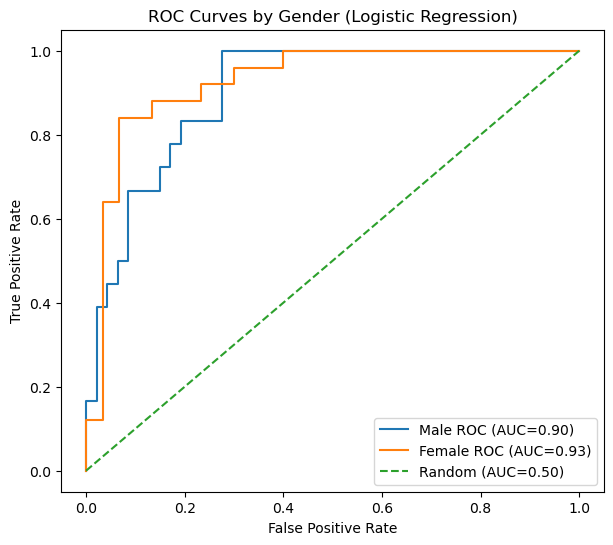

In [101]:
plt.figure(figsize=(7,6))

# Male ROC
if len(np.unique(y_male)) > 1:
    fpr_m, tpr_m, _ = roc_curve(y_male, p_male)
    auc_m = roc_auc_score(y_male, p_male)
    plt.plot(fpr_m, tpr_m, label=f"Male ROC (AUC={auc_m:.2f})")

# Female ROC
if len(np.unique(y_female)) > 1:
    fpr_f, tpr_f, _ = roc_curve(y_female, p_female)
    auc_f = roc_auc_score(y_female, p_female)
    plt.plot(fpr_f, tpr_f, label=f"Female ROC (AUC={auc_f:.2f})")

# Random baseline
plt.plot([0,1], [0,1], linestyle="--", label="Random (AUC=0.50)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves by Gender (Logistic Regression)")
plt.legend()
plt.show()

#### Findings of performance differential across gender
The results indicate a noticeable performance difference across gender, with the model performing better for females than males. The most significant differences are observed in precision (0.90 for females vs 0.71 for males) and recall (0.72 for females vs 0.56 for males), leading to a substantially higher F1-score for females (0.80 vs 0.63). This suggests that the model is more accurate and reliable in identifying female buyers compared to male buyers. Additionally, the higher AUC for females (0.93 vs 0.90) further confirms stronger classification performance for the female subgroup.